In [ ]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracycalculation
import matplotlib.pyplot as plt

In [ ]:
# Also practice describing the data as you get valuble insights from it, using - describe methods
pima_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
pima_df[['Outcome']].isin([1]).sum()
#268 / 768 is in has diabetes
# 500 / 768

,0
Outcome,268


In [ ]:
# Additionally you may look at the shape and information about the data for better
# understanding of what you are dealing with, using - info and shape
pima_df.info()
shape = pima_df.shape # YOUR CODE HERE
print(shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
(768, 9)


In [ ]:
#Always no a null check as it gives us an idea of whether or not we need to impute or drop any sample(s)
pima_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


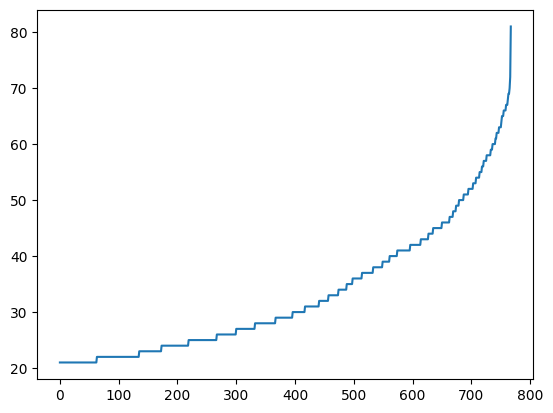

In [ ]:
x = [x for x in range(0,768)]
line = pima_df['Age'].sort_values()

plt.plot(x, line)

In [ ]:
pima_df['Glucose'] = pima_df['Glucose'].clip(lower=75)
pima_df['Insulin'] = pima_df['Insulin'].clip(lower=30, upper=200)
pima_df['BloodPressure'] = pima_df['BloodPressure'].clip(lower= 50, upper=90)
pima_df['SkinThickness'] = pima_df['SkinThickness'].clip(lower=10, upper=40)
pima_df['Pregnancies'] = pima_df['Pregnancies'].clip(upper=10)

pima_df['BMI'] = pima_df['BMI'].clip(lower=20, upper=40)

pima_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.742188,121.618490,71.080729,22.917969,79.953125,31.695573,0.471876,33.240885,0.348958
std,3.123898,30.248153,11.554248,11.152834,63.312354,5.848614,0.331329,11.760232,0.476951
min,0.000000,75.000000,50.000000,10.000000,30.000000,20.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,10.000000,30.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,10.000000,199.000000,90.000000,40.000000,200.000000,40.000000,2.420000,81.000000,1.000000


In [ ]:
# Split dataset into features and target variable --> make sure you use the correct column names while subsetting for X and y variables
# Use Outcome as the target variable (i.e. y variable) and the rest as features (i.e. X variable)
# Features
X = pima_df[pima_df.columns[0:8]] # YOUR CODE HERE
# Target variable
y = pima_df[['Outcome']]# YOUR CODE HERE

X.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.742188,121.618490,71.080729,22.917969,79.953125,31.695573,0.471876,33.240885
std,3.123898,30.248153,11.554248,11.152834,63.312354,5.848614,0.331329,11.760232
min,0.000000,75.000000,50.000000,10.000000,30.000000,20.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,10.000000,30.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,31.000000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,10.000000,199.000000,90.000000,40.000000,200.000000,40.000000,2.420000,81.000000


In [ ]:
from sklearn import preprocessing

def normalize():
  normalized = X.copy()

  normalizer = preprocessing.MinMaxScaler()
  normalized_df = normalizer.fit_transform(normalized.to_numpy())
  normalized_df = pd.DataFrame(data=normalized_df, columns=normalized.columns)

  return normalized_df[pima_df.columns[0:8]]

X = normalize()

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.6,0.588710,0.55,0.833333,0.000000,0.680,0.234415,0.483333
1,0.1,0.080645,0.40,0.633333,0.000000,0.330,0.116567,0.166667
2,0.8,0.870968,0.35,0.000000,0.000000,0.165,0.253629,0.183333
3,0.1,0.112903,0.40,0.433333,0.376471,0.405,0.038002,0.000000
4,0.0,0.500000,0.00,0.833333,0.811765,1.000,0.943638,0.200000


In [ ]:
# Split dataset into training set and test set - 80% traioning and 20% test --> try
# out other splits as well and check if you can get better results than the
# prescribed split of 80:20.
# Use random state as 1 but you are encouraged to play aropund with the values of # stratify=y
# random state as well
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # YOUR CODE HERE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

min_samples_leaf = 3
clf = None # YOUR CODE HERE
dtree_y_true = y_test

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [5, 10, 20],
    'criterion':["entropy"],
    'random_state':[100],
    'class_weight':['balanced']
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    params,
    cv=15
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print(grid.best_params_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 5, 'random_state': 100}


In [ ]:
grid.best_score_

np.float64(0.7166260162601625)

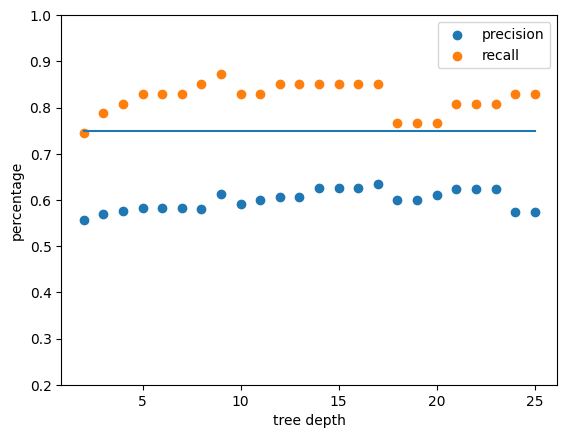

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

xAxis = []
precisionVals = []
recallVals = []

min = 2
max = 26

for val in range(min, max):
  clf = DecisionTreeClassifier( max_depth=6,
                                class_weight='balanced',
                                random_state=110,
                                criterion='gini',
                                min_samples_leaf=val,
                                min_samples_split=15,
                                ccp_alpha = 0.002)# YOUR CODE HERE

  # Train and Fit Decision Tree Classifer
  clf.fit(X_train, y_train)# YOUR CODE HERE

  dtree_y_pred = clf.predict(X_test)# YOUR CODE HERE

  precisionVals.append(precision_score(dtree_y_true, dtree_y_pred))
  recallVals.append(recall_score(dtree_y_true, dtree_y_pred))
  xAxis.append(val)

line = [.75 for i in range(min,max)]

plt.plot(xAxis, line)
plt.scatter(xAxis, precisionVals, label=f'precision')
plt.scatter(xAxis, recallVals, label=f'recall')
plt.xlabel('tree depth')
plt.ylabel('percentage')
plt.legend()
plt.ylim(0.2, 1.0)
plt.show()

In [ ]:
from sklearn.metrics import f1_score #Import scikit-learn metrics module for accuracycalculation

# Play around with the values of the DecisionTreeClassifier - change criterion and
# max_depth to find the best accuracy and report the same
# Prescribed parameters - criterion = "entropy", random_state = 100, max_depth = 3,

clf.min_samples_leaf=9
clf.fit(X_train, y_train)

#Predict the response for test dataset
dtree_y_pred = clf.predict(X_test)# YOUR CODE HERE

# Report the Accuracy, Recall, Precision and F1 score for the predictions that your classifier has made
# Use the metrics lib from sklearn previously imported. Also use 'weighted' as the average value for precision, recall and f1

dtree_y_true = y_test
accuracy = accuracy_score(dtree_y_true, dtree_y_pred)# Put the value of accuracy here -- 1.1 of Gradescope tests
precision = precision_score(dtree_y_true, dtree_y_pred)# Put the value of precision here -- 1.2 of Gradescope tests
recall = recall_score(dtree_y_true, dtree_y_pred)# Put the value of recall here -- 1.3 of Gradescope tests
f1_score = f1_score(dtree_y_true, dtree_y_pred) # Put the value of F1 score here -- 1.4 of Gradescope tests

#max_depth = 9
"""clf = DecisionTreeClassifier( max_depth=6,
                                class_weight='balanced',
                                random_state=100,
                                criterion='gini',
                                min_samples_leaf=val,
                                min_samples_split=30,
                                ccp_alpha = 0.00)# YOUR CODE HERE#"""

print("Accuracy:", accuracy) # -- 1.1
print("Precision Score:", precision) # -- 1.2
print("Recall Score: ", recall) # -- 1.3
print("F1 Score: ", f1_score) # -- 1.4

Accuracy: 0.7922077922077922
Precision Score: 0.6119402985074627
Recall Score:  0.8723404255319149
F1 Score:  0.7192982456140351


In [ ]:
# Here a template for writing the function for getting the tpr, fpr and threshold
# as well as AUC values is given as well as a simple way to plot the ROC curve
# you need to find out the predicted probabilities for the classifier you have
# written - using: redict_proba() function
# Pass these probabilities along with the y_true values into this function as
# specified and find the values mentioned above
# and report the AUC value and plot the ROC curve

from sklearn.metrics import roc_curve, auc
dtree_auc = 0
def plot_roc(dt_y_true, dt_probs):

  # Use sklearn.metrics.roc_curve() to get the values based on what the funciton returns - Read documentation here:
  # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
  dtree_fpr, dtree_tpr, threshold = roc_curve(dt_y_true, dt_probs)# YOUR CODE HERE

  # Use sklearn.metrics.auc() to get the AUC score of your model - Read documentation here:
  #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html
  dtree_auc_val = auc(dtree_fpr, dtree_tpr) # Put the AUC score here -- 1.5 of Gradescope tests

  # Report the AUC score for the model you have created
  print('AUC=%0.2f'%dtree_auc_val) # -- 1.6

  # Plot the ROC curve using the probabilities and the true y values as passed
  #into the fuction we have defined here
  plt.plot(dtree_fpr, dtree_tpr, label = 'AUC=%0.2f'%dtree_auc_val, color ='darkorange')
  plt.legend(loc = 'lower right')
  plt.plot([0,1], [0,1], 'b--')
  plt.xlim([0,1])
  plt.ylim([0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.show()
  return dtree_auc_val

AUC=0.84


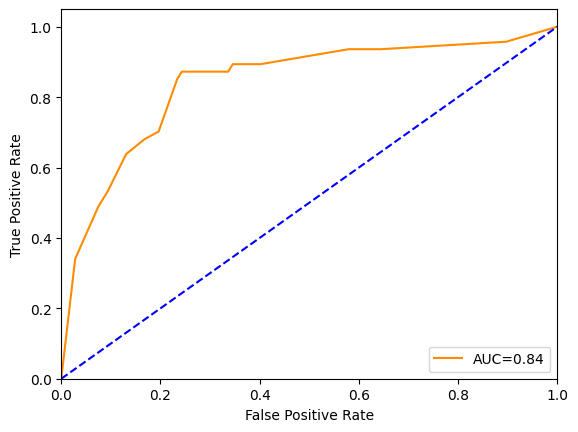

In [ ]:
# We pass in the following parameters to the custom function we have written. For details as to why we do this - Read here:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
#sklearn.metrics.roc_auc_score
dtree_probs = clf.predict_proba(X_test) [:,1]

dtree_auc = plot_roc(dtree_y_true, dtree_probs) # 1.5 (this is where the value is returned by the function and verified)

In [ ]:
# Report which cross validation value of k gave the best result as well as the max accuracy score -
#use StrafiedKFold Cross Validation method for 2 - 10 folds - Read
# about it here: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html
#sklearn.model_selection.RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

max_acc, max_k = 0, 0

for k in range(2, 16):
  skfold = StratifiedKFold(shuffle=True,n_splits=k,random_state=100)#YOUR CODE HERE FOR: StratifiedKFold() - use random_state = 100,
  results_skfold_acc = (cross_val_score(clf, X, y, cv = skfold)).mean() * 100.0

  if results_skfold_acc > max_acc: # conditional check for getting max value and corresponding k value
    max_acc = results_skfold_acc
    max_k = k
    # YOUR CODE HERE

  print("Accuracy: %.2f%%" % (results_skfold_acc))

best_accuracy = max_acc # Put the accuracy score here from the values that you got -- 1.6 of Gradescope tests
best_k_fold = max_k # Put the value of k that gives the best accuracy here # -- 1.7 of Gradescope tests
print(best_accuracy, best_k_fold)

Accuracy: 70.05%
Accuracy: 69.92%
Accuracy: 72.01%
Accuracy: 72.66%
Accuracy: 73.18%
Accuracy: 70.96%
Accuracy: 72.40%
Accuracy: 71.62%
Accuracy: 70.57%
Accuracy: 71.74%
Accuracy: 72.14%
Accuracy: 69.78%
Accuracy: 72.38%
Accuracy: 71.21%
73.17708333333334 6
